<a href="https://colab.research.google.com/github/thisishasan/cbir_system/blob/main/05_train_auto_encoder_magnification_1_200.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd '/content/drive/My Drive/01_information_retrieval'
!ls

/content/drive/My Drive/01_information_retrieval
binary_scenario  subclass_scenario  training_1_100.json  training_1_40.json
Notes.gdoc	 training_1_100     training_1_40
original	 training_1_100.h5  training_1_40.h5


In [3]:
import matplotlib
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import json

In [4]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Conv2DTranspose
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.layers import Activation
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Reshape
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
import numpy as np

In [12]:
class ConvAutoEncoder:
    @staticmethod
    def build(width, height, depth, filters=(128,), latent_dim=48):
        input_shape = (height, width, depth)
        channel_dim = -1
        inputs = Input(shape=input_shape)
        x = inputs
        # Encoder layer
        for f in filters:
            x = Conv2D(f, (3, 3), strides=2, padding='same')(x)
            x = LeakyReLU(negative_slope=0.2)(x)
            x = BatchNormalization(axis=channel_dim, name='enc_filter_'+str(f))(x)

        volume_size = K.int_shape(x)
        x = Flatten()(x)
        # Latent layer
        latent = Dense(latent_dim, name="encoded")(x)

        # Decoder layer
        x = Dense(int(np.prod(volume_size[1:])))(latent)
        x = Reshape((volume_size[1], volume_size[2], volume_size[3]))(x)

        # Reverse on decoder
        for f in filters[::-1]:
            x = Conv2DTranspose(f, (3, 3), strides=2, padding='same')(x)
            x = LeakyReLU(negative_slope=0.2)(x)
            x = BatchNormalization(axis=channel_dim, name='dec_filter_'+str(f))(x)

        x = Conv2DTranspose(depth, (3, 3), padding="same")(x)
        outputs = Activation("sigmoid", name="decoded")(x)

        auto_encoder = Model(inputs, outputs, name="auto_encoder")
        return auto_encoder

In [6]:
def visualize_predictions(_decoded, gt, samples=10):
    outputs = None
    for i in range(0, samples):
        original = (gt[i] * 255).astype("uint8")
        recon = (_decoded[i] * 255).astype("uint8")
        output = np.hstack([original, recon])
        outputs = output if outputs is None else np.vstack([outputs, output])
    return outputs

In [14]:
EPOCHS = 50
INIT_LR = 1e-3
BS = 32
IMAGE_SIZE = (256, 256)
checkpoint_path = "training_1_200/cp.ckpt.weights.h5"
checkpoint_dir = os.path.dirname(checkpoint_path)

In [8]:
print("[INFO] indexing file images BreaKHis dataset...")
using_magnification = '200X'
base_dataset = "binary_scenario"
class_dir = ['benign', 'malignant']
type_dataset = ['val', 'train']
dataset_train = []
dataset_val = []
for type_set in type_dataset:
    for class_item in class_dir:
        cur_dir = os.path.join(base_dataset, type_set, using_magnification ,class_item)
        for file in os.listdir(cur_dir):
            if type_set == 'train':
                dataset_train.append(os.path.join(cur_dir, file))
            else:
                dataset_val.append(os.path.join(cur_dir, file))

[INFO] indexing file images BreaKHis dataset...


In [9]:
print("[INFO] load images BreaKHis dataset...")
#  load images
train_images = []
val_images = []
for type_set in type_dataset:
    cur_dataset = dataset_train if type_set == 'train' else dataset_val
    for image_path in cur_dataset:
        if ".png" in image_path:
            image = cv2.imread(image_path)
            image = cv2.resize(image, IMAGE_SIZE)
            if type_set == 'train':
                train_images.append(image)
            else:
                val_images.append(image)

[INFO] load images BreaKHis dataset...


In [10]:
# normalization
print("[INFO] normalization...")
train_x = np.array(train_images).astype("float32") / 255.0
val_x = np.array(val_images).astype("float32") / 255.0

[INFO] normalization...


In [15]:
print("[INFO] building auto encoder...")
auto_encoder = ConvAutoEncoder.build(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)
opt = Adam(learning_rate=INIT_LR)
checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=True,
    monitor="val_loss",
    verbose = 1,
    mode='min',
    save_best_only=True)
auto_encoder.compile(loss="mse", optimizer=opt)
auto_encoder.summary()

[INFO] building auto encoder...


Model: "auto_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 128)  │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_filter_128                  │ (None, 128, 128, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2097152)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (Dense)                 │ (None, 48)             │   100,663,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2097152)        │   102,760,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 256, 256, 128)  │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 256, 256, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_filter_128                  │ (None, 256, 256, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 256, 256, 3)    │         3,459 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Activation)            │ (None, 256, 256, 3)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,579,443 (776.59 MB)

 Trainable params: 203,578,931 (776.59 MB)

 Non-trainable params: 512 (2.00 KB)

In [16]:
# train the convolutional auto encoder
print("[INFO] training auto encoder...")
H = auto_encoder.fit(
    train_x, train_x,
    shuffle=True,
    validation_data=(val_x, val_x),
    epochs=EPOCHS,
    callbacks = [checkpoint_callback],
    batch_size=BS)

[INFO] training auto encoder...
Epoch 1/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 709ms/step - loss: 0.0807
Epoch 1: val_loss improved from None to 0.03926, saving model to training_1_200/cp.ckpt.weights.h5

Epoch 1: finished saving model to training_1_200/cp.ckpt.weights.h5
51/51 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - loss: 0.0555 - val_loss: 0.0393
Epoch 2/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - loss: 0.0219
Epoch 2: val_loss improved from 0.03926 to 0.01961, saving model to training_1_200/cp.ckpt.weights.h5

Epoch 2: finished saving model to training_1_200/cp.ckpt.weights.h5
51/51 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - loss: 0.0207 - val_loss: 0.0196
Epoch 3/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - loss: 0.0155
Epoch 3: val_loss did not improve from 0.01961
51/51 ━━━━━━━━━━━━━━━━━━━━ 17s 329ms/step - loss: 0.0145 - val_loss: 0.0273
Epoch 4/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - loss: 0.0134
Epoch 4: val_loss did not improve from 0.01961
51/51 ━━━━━━━━━━━━━━━━━━━━ 18s 342ms/step - l

[INFO] making predictions...
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 193ms/step


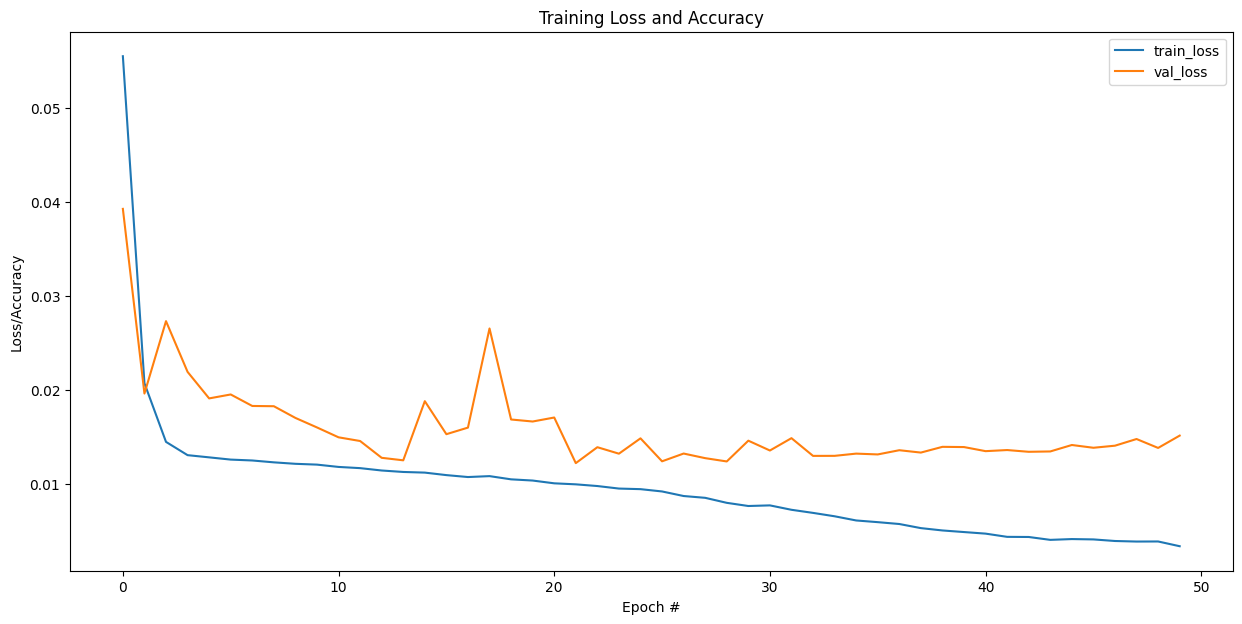

In [17]:
print("[INFO] making predictions...")
decoded = auto_encoder.predict(val_x)
vis = visualize_predictions(decoded, val_x)
image_example_path = "reconstruction"
cv2.imwrite(os.path.join(image_example_path,"recon_vis.png"), vis)
N = np.arange(0, EPOCHS)
plt.figure(figsize=(15,7))
plt.plot(N, H.history["loss"], label="train_loss")
plt.plot(N, H.history["val_loss"], label="val_loss")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()
plt.show()

In [18]:
with open('training_1_200.json', 'w') as f:
    json.dump(H.history, f)

In [19]:
auto_encoder.save('training_1_200.h5')